In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime as dt
import sys
from pathlib import Path

import pandas as pd
from river import utils
from river.proba import Gaussian

sys.path.insert(1, str(Path.cwd().parent))
from publications.ilustrate.pc2023.plot_matplotlib import plot_limits_grid_
from safeband.anomaly import GaussianScorer
from safeband.evaluate import progressive_val_predict
from safeband.proba import MultivariateGaussian

In [3]:
df = pd.read_csv("data/data_BESS_norm.csv", index_col=0)
df.index = pd.to_datetime(df.index, utc=True)

In [4]:
# CONSTANTS
days = 4
WINDOW = dt.timedelta(hours=24 * days)
minutes = int(WINDOW.total_seconds() / 60)
GRACE_PERIOD = dt.timedelta(minutes=minutes / 4)
THRESHOLD = 0.9995

model = GaussianScorer(
    utils.TimeRolling(MultivariateGaussian(), period=WINDOW),
    grace_period=GRACE_PERIOD,
    t_a=60 * 3,
    threshold=THRESHOLD,
)


sampling_model = GaussianScorer(
    Gaussian()._from_state(minutes, 60, 60**2, 1),
    protect_anomaly_detector=False,
)

system_anomaly, meta = progressive_val_predict(
    model=model,
    dataset=df,
    compute_limits=True,
    detect_signal=True,
    detect_change=True,
    sampling_model=sampling_model,
)

df_out = pd.DataFrame(
    {"System Anomaly": system_anomaly, **meta},
    index=df.index,
)

/usr/local/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Avg. latency per sample: 0.6679568260567107ms


In [5]:
events_count = sum(pd.Series(system_anomaly).diff().dropna() == 1)
text = (
    f"Sliding window: {WINDOW}\n"
    f"Proportion of anomalous samples: "
    f"{sum(system_anomaly) / len(system_anomaly) * 100:.02f}%\n"
    f"Anomaly every: "
    f"{len(system_anomaly) / sum(system_anomaly):.00f} samples\n"
    f"Total number of anomalous events: "
    f"{events_count}\n"
    f"Anomalous event every: "
    f"{len(system_anomaly) / events_count:.00f} samples\n"
    f"Total number of change points: "
    f"{sum(df_out['Changepoint'].diff().dropna() == 1)}\n"
    f"Total number of sampling anomalies: "
    f"{sum(df_out['Sampling Anomaly'].diff().dropna() == 1)}"
)

Sliding window: 4 days, 0:00:00
Proportion of anomalous samples: 2.09%
Anomaly every: 48 samples
Total number of anomalous events: 2
Anomalous event every: 6248 samples
Total number of change points: 2
Total number of sampling anomalies: 3


/workspaces/safeband/publications/ilustrate/pc2023/plot_matplotlib.py:336: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(
/workspaces/safeband/publications/ilustrate/pc2023/plot_matplotlib.py:360: FutureWarning: 't' is deprecated and will be removed in a future version, please use 'min' instead.
  ser_ = ser.resample(rule=kwargs["resample"]).asfreq()


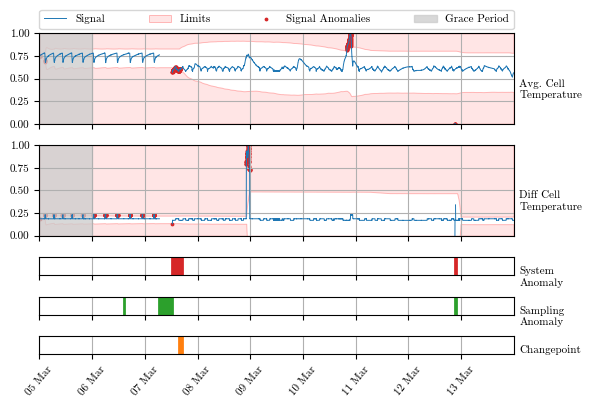

In [6]:
plot_limits_grid_(
    df,
    df_out["Changepoint"],
    df_out["Sampling Anomaly"],
    df_out["System Anomaly"],
    ser_high=df_out["Limit High"].iloc[1:],
    ser_low=df_out["Limit Low"].iloc[1:],
    signal_anomaly=df_out["Signal Anomaly"],
    file_name="TERRA",
    save=False,
    resample="1t",
    grace_period=GRACE_PERIOD,
)